In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Angle Addition Identities for trigonometric functions

We can determine the position after two successive rotations using these identities

$$AC = \sin(\alpha+\beta) = \sin\alpha\cos\beta + \cos\alpha\sin\beta$$
$$BC = \cos(\alpha+\beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta$$

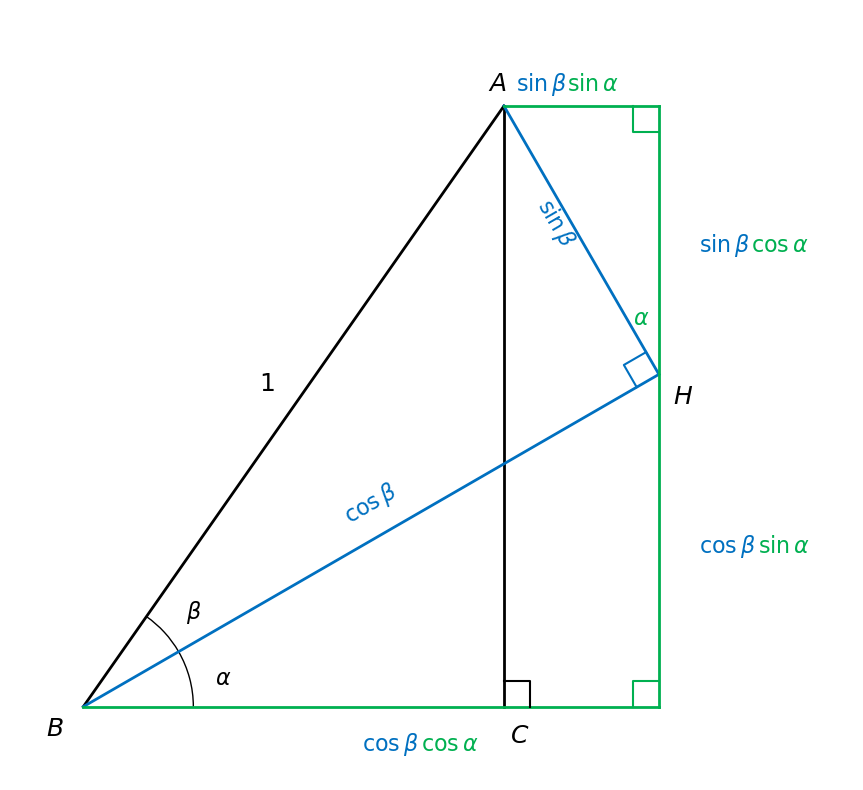

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Arc

def draw_trig_identities_diagram():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. 각도 및 기본 설정 (이미지 비율과 가장 유사한 각도)
    alpha_deg = 30
    beta_deg = 25
    alpha = np.radians(alpha_deg)
    beta = np.radians(beta_deg)
    
    # 2. 좌표 정밀 계산
    B = np.array([0, 0])
    D = np.array([np.cos(beta) * np.cos(alpha), 0]) # 오른쪽 아래 모서리
    H = np.array([np.cos(beta) * np.cos(alpha), np.cos(beta) * np.sin(alpha)])
    E = np.array([D[0], np.sin(alpha + beta)]) # 오른쪽 위 모서리
    A = np.array([np.cos(alpha + beta), np.sin(alpha + beta)])
    C = np.array([A[0], 0])
    
    # 색상 설정 (이미지와 유사한 톤)
    c_black = 'black'
    c_blue = '#0070C0'
    c_green = '#00B050'
    
    # 3. 선 그리기
    # 검은색 선 (빗변, 내부 수직선)
    ax.plot([B[0], A[0]], [B[1], A[1]], color=c_black, lw=2)
    ax.plot([A[0], C[0]], [A[1], C[1]], color=c_black, lw=2)
    
    # 파란색 선 (내부 삼각형)
    ax.plot([B[0], H[0]], [B[1], H[1]], color=c_blue, lw=2)
    ax.plot([A[0], H[0]], [A[1], H[1]], color=c_blue, lw=2)
    
    # 초록색 선 (외부 직사각형 테두리)
    ax.plot([B[0], D[0]], [B[1], D[1]], color=c_green, lw=2) # 바닥
    ax.plot([D[0], E[0]], [D[1], E[1]], color=c_green, lw=2) # 오른쪽 벽
    ax.plot([E[0], A[0]], [E[1], A[1]], color=c_green, lw=2) # 지붕
    
    # 4. 직각 기호 그리기 함수
    def draw_right_angle(pt, vec1, vec2, size=0.035, color=c_black):
        v1 = vec1 / np.linalg.norm(vec1)
        v2 = vec2 / np.linalg.norm(vec2)
        p1 = pt + v1 * size
        p2 = p1 + v2 * size
        p3 = pt + v2 * size
        ax.plot([p1[0], p2[0], p3[0]], [p1[1], p2[1], p3[1]], color=color, lw=1.5)

    # 직각 기호 추가
    draw_right_angle(C, np.array([1, 0]), np.array([0, 1]), color=c_black)
    draw_right_angle(D, np.array([-1, 0]), np.array([0, 1]), color=c_green)
    draw_right_angle(E, np.array([-1, 0]), np.array([0, -1]), color=c_green)
    draw_right_angle(H, B - H, A - H, color=c_blue)
    
    # 5. 각도 호 (Arc) 그리기
    arc_radius = 0.15
    ax.add_patch(Arc(B, arc_radius*2, arc_radius*2, angle=0, theta1=0, theta2=alpha_deg, color=c_black, lw=1))
    ax.add_patch(Arc(B, arc_radius*2, arc_radius*2, angle=0, theta1=alpha_deg, theta2=alpha_deg+beta_deg, color=c_black, lw=1))
    
    # 6. 텍스트 라벨링
    # 꼭짓점 (이탤릭체)
    ax.text(B[0] - 0.05, B[1] - 0.04, 'B', fontsize=18, fontstyle='italic')
    ax.text(C[0] + 0.01, C[1] - 0.05, 'C', fontsize=18, fontstyle='italic')
    ax.text(A[0] - 0.02, A[1] + 0.02, 'A', fontsize=18, fontstyle='italic')
    ax.text(H[0] + 0.02, H[1] - 0.04, 'H', fontsize=18, fontstyle='italic')
    
    # 각도 기호
    ax.text(0.18, 0.03, r'$\alpha$', fontsize=16)
    ax.text(0.14, 0.12, r'$\beta$', fontsize=16)
    ax.text(0.75, 0.52, r'$\alpha$', fontsize=16, color=c_green) # AC와 AH 사이의 각도
    
    # 빗변 길이 및 파란색 단일 수식
    ax.text(0.24, 0.43, '1', fontsize=18)
    ax.text(0.35, 0.25, r'$\cos \beta$', fontsize=16, color=c_blue, rotation=alpha_deg)
    ax.text(0.61, 0.63, r'$\sin \beta$', fontsize=16, color=c_blue, rotation=alpha_deg-90)
    
    # 두 가지 색상이 결합된 수식들 (위치를 미세 조정하여 나란히 배치)
    # 아래쪽 (cos β cos α)
    ax.text(0.38, -0.06, r'$\cos \beta$', fontsize=16, color=c_blue)
    ax.text(0.46, -0.06, r'$\cos \alpha$', fontsize=16, color=c_green)
    
    # 오른쪽 아래 (cos β sin α)
    ax.text(0.84, 0.21, r'$\cos \beta$', fontsize=16, color=c_blue)
    ax.text(0.92, 0.21, r'$\sin \alpha$', fontsize=16, color=c_green)
    
    # 오른쪽 위 (sin β cos α)
    ax.text(0.84, 0.62, r'$\sin \beta$', fontsize=16, color=c_blue)
    ax.text(0.91, 0.62, r'$\cos \alpha$', fontsize=16, color=c_green)
    
    # 위쪽 (sin β sin α)
    ax.text(0.59, 0.84, r'$\sin \beta$', fontsize=16, color=c_blue)
    ax.text(0.66, 0.84, r'$\sin \alpha$', fontsize=16, color=c_green)

    # 7. 화면 출력 설정
    ax.set_aspect('equal')
    ax.axis('off') # 축 숨기기
    plt.xlim(-0.1, 1.05)
    plt.ylim(-0.1, 0.95)
    
    plt.tight_layout()
    plt.show()

# 함수 실행
draw_trig_identities_diagram()